In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from numpy.polynomial.legendre import leggauss

In [4]:
#### Parâmetros físicos (adimensionais) ####
m0 = 0.0           # massa nua
Lambda_UV = 1e5    # corte UV
Lambda_IR = 1e-9   # corte infravermelho

#### Parâmetros numéricos ####
N = 500            # pontos de Gauss-Legendre (pelo menos 500)
tol = 1e-8         # tolerância
max_iter = 1500    # número máximo de iterações
relax = 1.0        # relaxação

#### Pontos e pesos de Gauss-Legendre em z = ln(y) ####
z_min, z_max = np.log(Lambda_IR**2), np.log(Lambda_UV**2)
nodes, weights = leggauss(N)
## Mapeamento [-1,1] --> [z_min, z_max] ##
z_vals = 0.5 * (z_max - z_min) * nodes + 0.5 * (z_max + z_min)
w_z = 0.5 * (z_max - z_min) * weights
## Converter de volta para y ##
y_vals = np.exp(z_vals)
## O peso efetivo é e^z * w_z ##
w_eff = y_vals * w_z

#### Chute inicial ####
# B = np.ones_like(y_vals) * 1e-5 
# muito pequeno, mas não exatamente 0
g_range = np.logspace(np.log10(13.2), np.log10(30), 50)
B0 = np.zeros((len(g_range), len(y_vals)))

#### Iteração de ponto fixo ####
for ig, g in enumerate(g_range):
    B = np.ones_like(y_vals) * 1e-5
    for it in range(max_iter):
        B_new = np.zeros_like(B)
        for i, x, in enumerate(y_vals):
            integrand = (y_vals / np.maximum(x, y_vals)) * (B / (y_vals + B**2)) # define o integrando
            integral = np.sum(w_eff * integrand)                                 # calcula a integral
            B_new[i] = m0 + (3 * g / (16 * np.pi**2)) * integral                 # calcula B^(n+1)
        B_new = (1 - relax) * B + relax * B_new                                  # relaxação
        diff = np.max(np.abs(B_new - B))                                         # calcula a diferença
        if it % 10 == 0:
            print(f'Iteração {it:4d}: diferença = {diff:3e}')
        if diff < tol:
            print(f"Convergiu na iteração {it}")
            break
        B = B_new
    else:
        print("Atenção: número máximo de iterações atingido")
    B0[ig] = B
print('Concluído')

#### Converter para p = sqrt(x) ####
p_vals = np.sqrt(y_vals) / Lambda_UV
# p_vals = y_vals / 1e5
B_vals = B

Iteração    0: diferença = 1.054838e-04
Iteração   10: diferença = 4.447620e-03
Iteração   20: diferença = 5.024805e-04
Iteração   30: diferença = 5.756198e-04
Iteração   40: diferença = 7.134378e-04
Iteração   50: diferença = 6.501009e-04
Iteração   60: diferença = 5.551363e-04
Iteração   70: diferença = 4.663967e-04
Iteração   80: diferença = 3.910110e-04
Iteração   90: diferença = 3.282176e-04
Iteração  100: diferença = 2.764461e-04
Iteração  110: diferença = 2.334857e-04
Iteração  120: diferença = 1.979432e-04
Iteração  130: diferença = 1.682747e-04
Iteração  140: diferença = 1.435309e-04
Iteração  150: diferença = 1.227742e-04
Iteração  160: diferença = 1.052875e-04
Iteração  170: diferença = 9.057811e-05
Iteração  180: diferença = 7.810970e-05
Iteração  190: diferença = 6.751357e-05
Iteração  200: diferença = 5.850900e-05
Iteração  210: diferença = 5.082507e-05
Iteração  220: diferença = 4.424366e-05
Iteração  230: diferença = 3.859375e-05
Iteração  240: diferença = 3.373513e-05


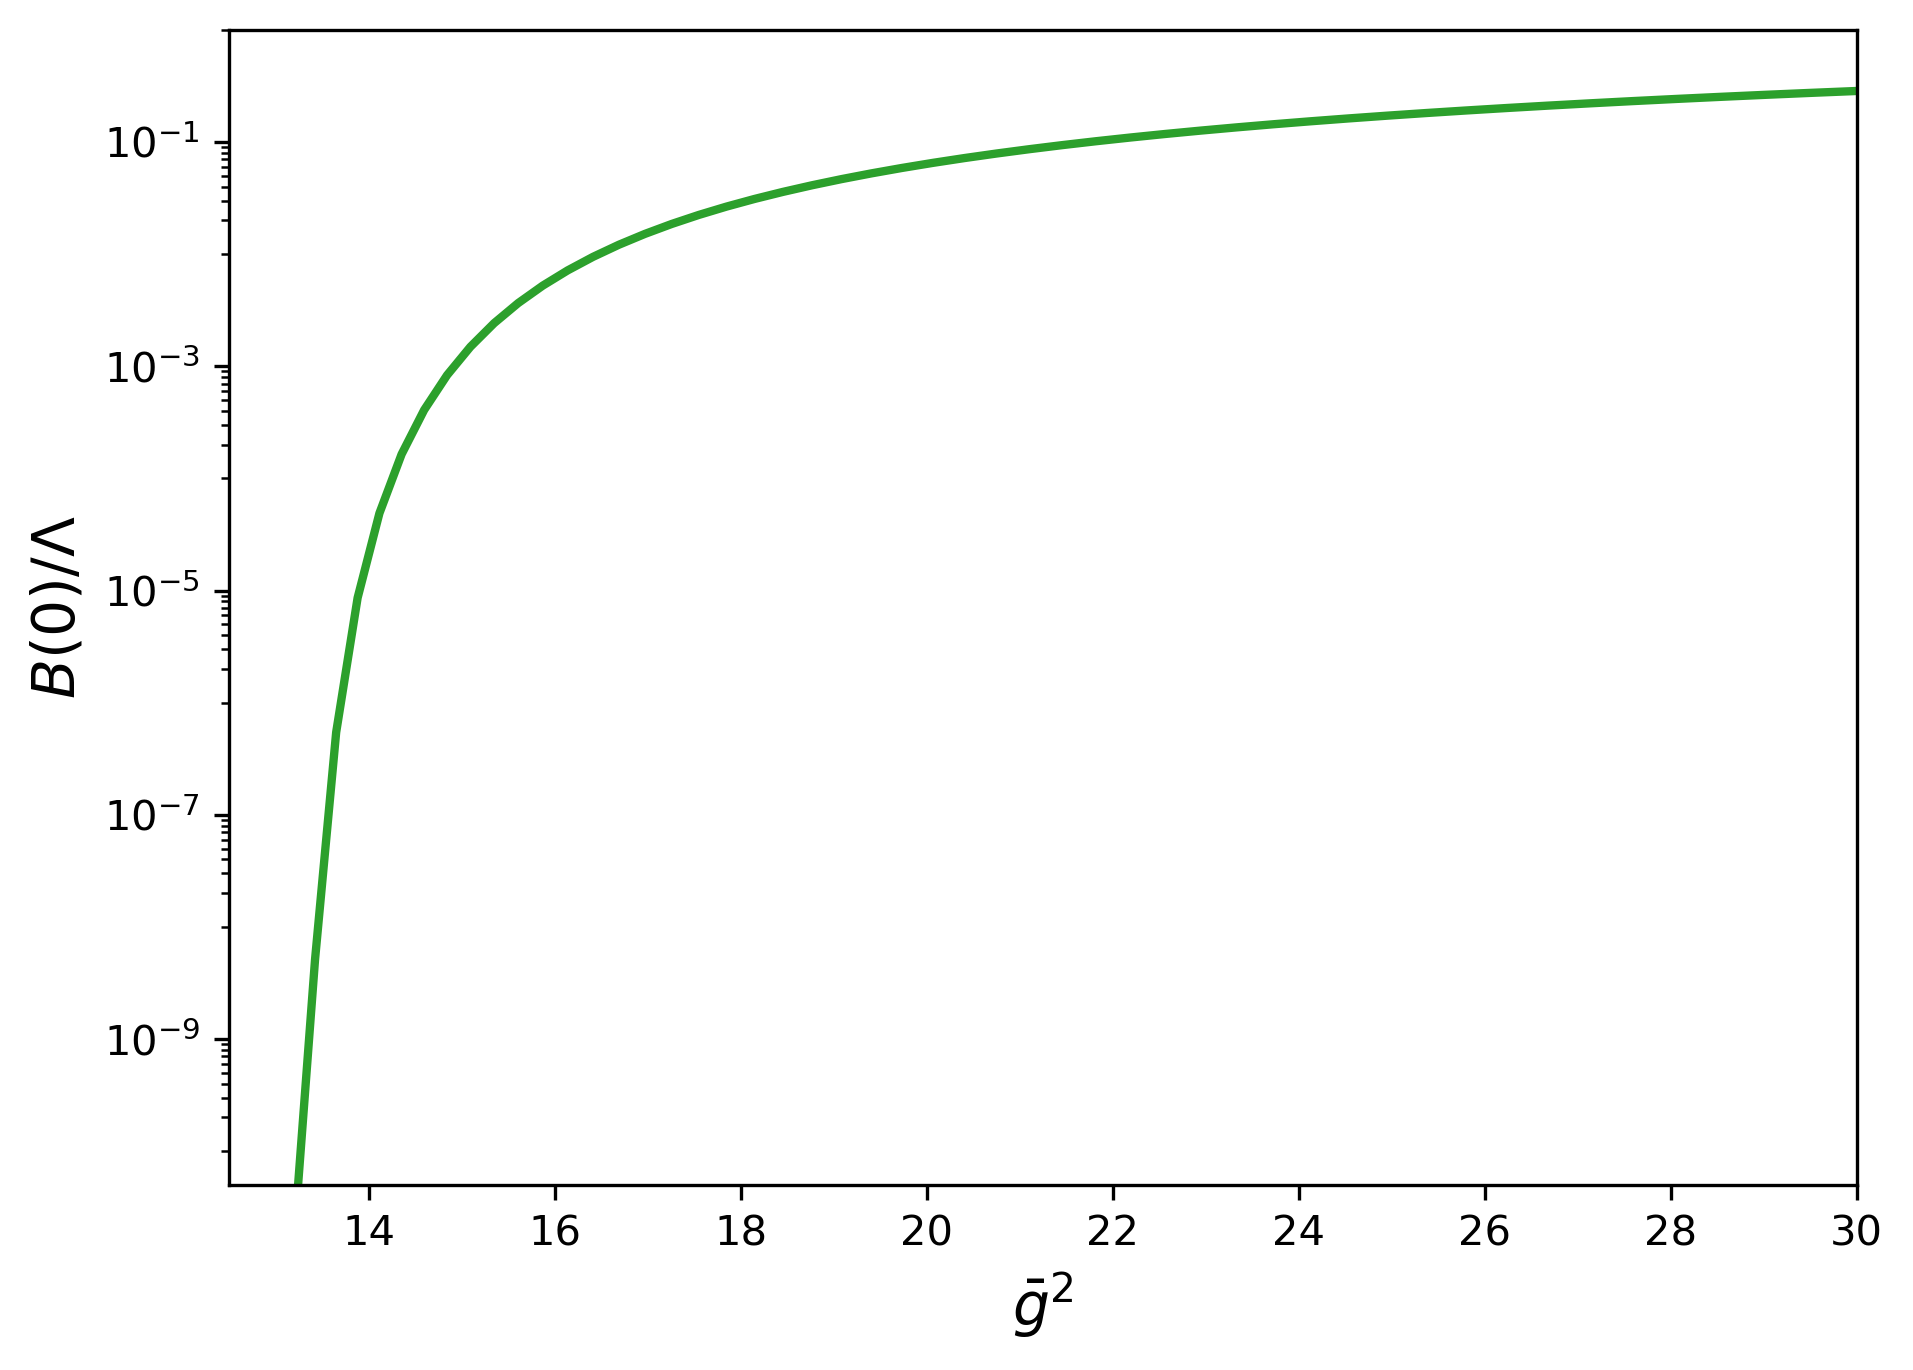

In [9]:
# B(p^2)/B(0) vs. p
plt.figure(figsize=(7,5))
plt.plot(g_range, B0[:,0] / Lambda_UV, color="tab:green", lw=2)
plt.yscale('log')
plt.xlim([12.5, 30])
plt.ylim([0.5e-10, 1])

ax = plt.gca()
ax.yaxis.set_minor_locator(LogLocator(base=100.0, subs=[9,8,7,6,5,4,3,2,1], numticks=100)) # mostra os minor ticks
ax.yaxis.set_minor_formatter(plt.NullFormatter())  # remove os números dos minor ticks

plt.xlabel(r"$\bar{g}^2$", fontsize=14)
plt.ylabel(r"$B(0)/\Lambda$", fontsize=14)
# plt.title(r"Massa Dinâmica com o Acoplamento em $p=0$", fontsize=14)
plt.grid(True, which="both", ls=":", alpha=0.0)
plt.rcParams['figure.dpi'] = 300
plt.show()

In [6]:
g_range

array([13.2       , 13.42302525, 13.64981871, 13.88044403, 14.11496596,
       14.35345034, 14.59596412, 14.84257538, 15.09335334, 15.34836841,
       15.60769218, 15.87139744, 16.13955823, 16.41224982, 16.68954877,
       16.97153293, 17.25828144, 17.54987482, 17.84639491, 18.14792497,
       18.45454963, 18.76635498, 19.08342854, 19.40585933, 19.73373787,
       20.06715619, 20.4062079 , 20.75098818, 21.10159381, 21.45812322,
       21.82067651, 22.18935544, 22.56426351, 22.94550598, 23.33318986,
       23.72742399, 24.12831905, 24.53598756, 24.95054399, 25.3721047 ,
       25.80078803, 26.23671434, 26.68000599, 27.13078744, 27.58918522,
       28.05532802, 28.5293467 , 29.01137433, 29.50154623, 30.        ])

In [7]:
B0

array([[1.80041686e-06, 1.80041686e-06, 1.80041686e-06, ...,
        3.46008156e-17, 3.45021549e-17, 3.44474049e-17],
       [5.16485102e-04, 5.16485102e-04, 5.16485102e-04, ...,
        2.75184866e-12, 2.74400209e-12, 2.73964776e-12],
       [5.44396213e-02, 5.44396213e-02, 5.44396213e-02, ...,
        3.02755361e-08, 3.01892101e-08, 3.01413044e-08],
       ...,
       [2.63839062e+04, 2.63839062e+04, 2.63839062e+04, ...,
        4.85929070e+03, 4.84544794e+03, 4.83776108e+03],
       [2.74682886e+04, 2.74682886e+04, 2.74682886e+04, ...,
        5.22052132e+03, 5.20564995e+03, 5.19739173e+03],
       [2.85637241e+04, 2.85637241e+04, 2.85637241e+04, ...,
        5.59541320e+03, 5.57947436e+03, 5.57062320e+03]])